In [3]:
import sys
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(
    os.path.abspath("..")
)

from src.features.feature_engineering import create_features

In [4]:
df = pd.read_excel(
    r"C:\Users\kondu\Downloads\GenAI-Knowledge-Assistant-main\ds cs\forecasting-system\data\raw\sales_data.xlsx"
)

df.columns = df.columns.str.strip().str.lower()

df.rename(columns={
    'total': 'sales'
}, inplace=True)

df['date'] = pd.to_datetime(
    df['date'],
    dayfirst=True
)

In [5]:
feature_df = create_features(df)

print(feature_df.head())

        state       date        sales   category        lag_1        lag_7  \
559   Alabama 2020-05-07  138414683.2  Beverages  123259529.2  127145065.2   
4343  Alabama 2020-05-17  130340051.0  Beverages  138414683.2  116657084.0   
6192  Alabama 2020-05-24  134708618.7  Beverages  130340051.0  133713630.0   
7955  Alabama 2020-05-31  129887876.9  Beverages  134708618.7  117742073.2   
602   Alabama 2020-06-09  137905687.0  Beverages  129887876.9  118114595.0   

           lag_30  rolling_mean_7  rolling_std_7  day_of_week  month  \
559   109574036.0    1.217345e+08   1.143778e+07            3      5   
4343  112189103.8    1.236892e+08   1.159357e+07            6      5   
6192  129106730.4    1.238314e+08   1.174210e+07            6      5   
7955  108083723.8    1.255665e+08   1.158871e+07            6      5   
602   110932912.8    1.283938e+08   1.187827e+07            1      6   

      is_holiday  
559            0  
4343           0  
6192           1  
7955           1  
602

In [6]:
print(feature_df.columns.tolist())

['state', 'date', 'sales', 'category', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'month', 'is_holiday']


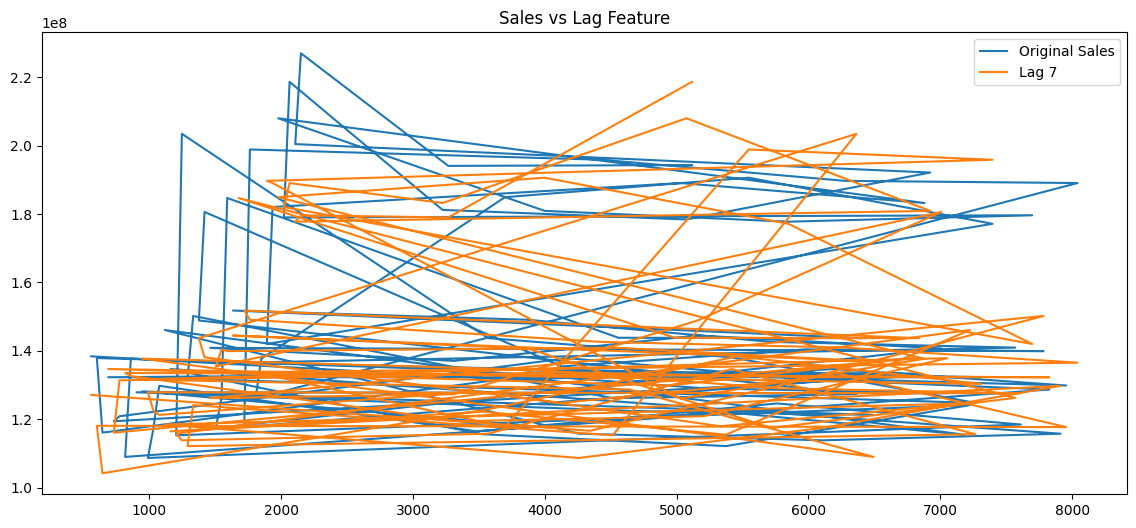

In [7]:
plt.figure(figsize=(14,6))

plt.plot(
    feature_df['sales'].head(100),
    label='Original Sales'
)

plt.plot(
    feature_df['lag_7'].head(100),
    label='Lag 7'
)

plt.legend()

plt.title("Sales vs Lag Feature")

plt.show()

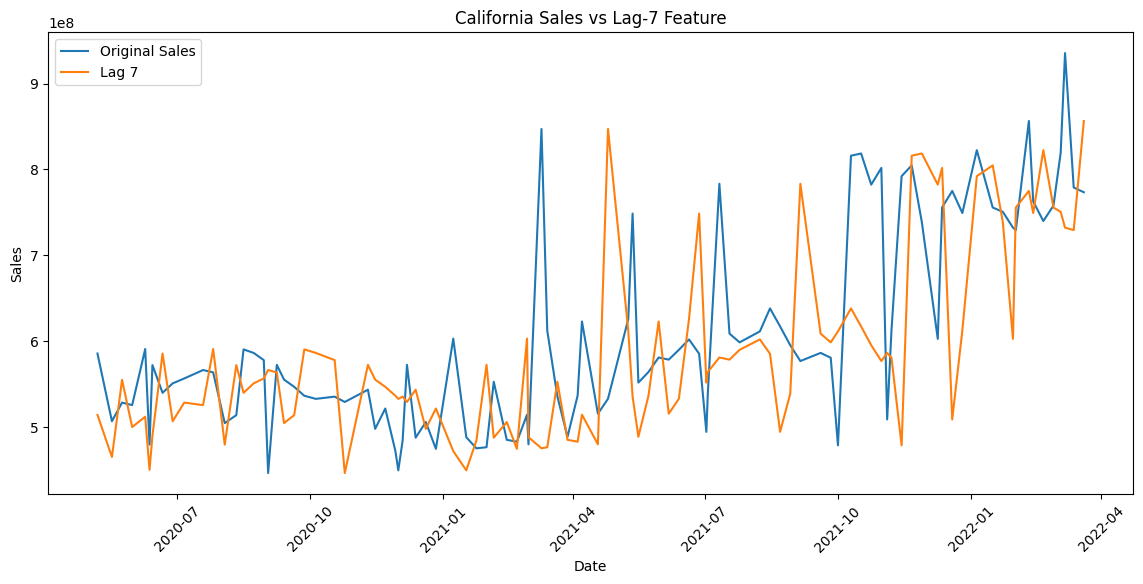

In [11]:
state_df = feature_df[
    feature_df['state'] == 'California'
].copy()

state_df = state_df.sort_values('date')

plt.figure(figsize=(14,6))

plt.plot(
    state_df['date'].head(100),
    state_df['sales'].head(100),
    label='Original Sales'
)

plt.plot(
    state_df['date'].head(100),
    state_df['lag_7'].head(100),
    label='Lag 7'
)

plt.legend()

plt.title("California Sales vs Lag-7 Feature")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

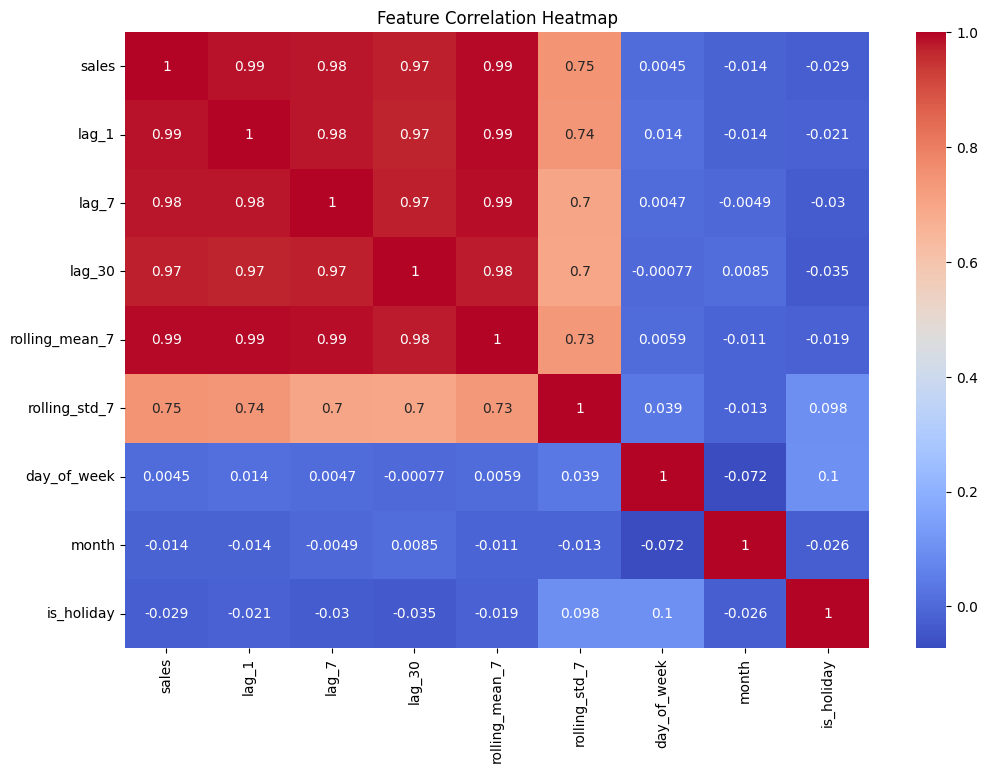

In [9]:
plt.figure(figsize=(12,8))

sns.heatmap(
    feature_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

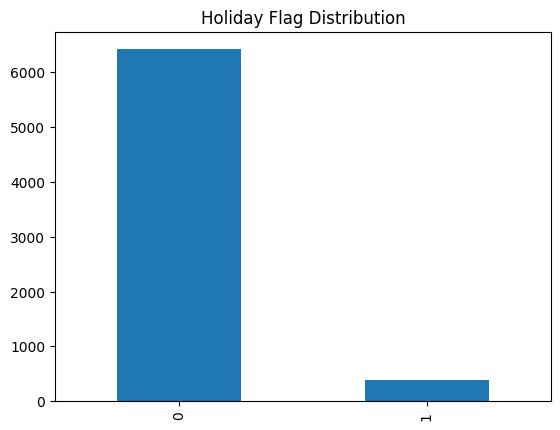

In [10]:
feature_df['is_holiday'].value_counts().plot(
    kind='bar'
)

plt.title("Holiday Flag Distribution")

plt.show()

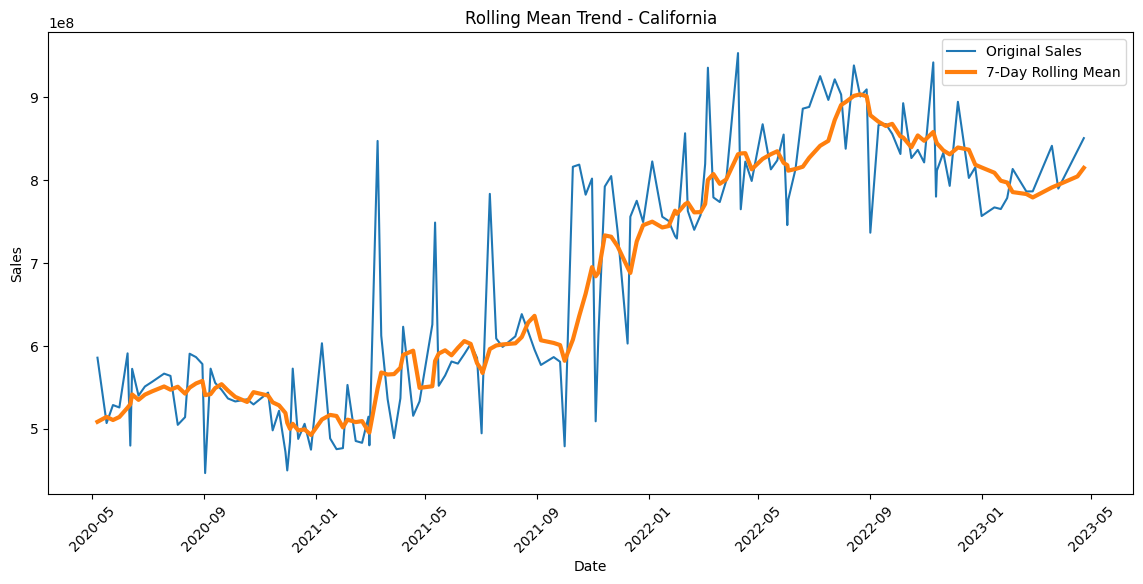

In [12]:
plt.figure(figsize=(14,6))

plt.plot(
    state_df['date'].head(150),
    state_df['sales'].head(150),
    label='Original Sales'
)

plt.plot(
    state_df['date'].head(150),
    state_df['rolling_mean_7'].head(150),
    label='7-Day Rolling Mean',
    linewidth=3
)

plt.legend()

plt.title("Rolling Mean Trend - California")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

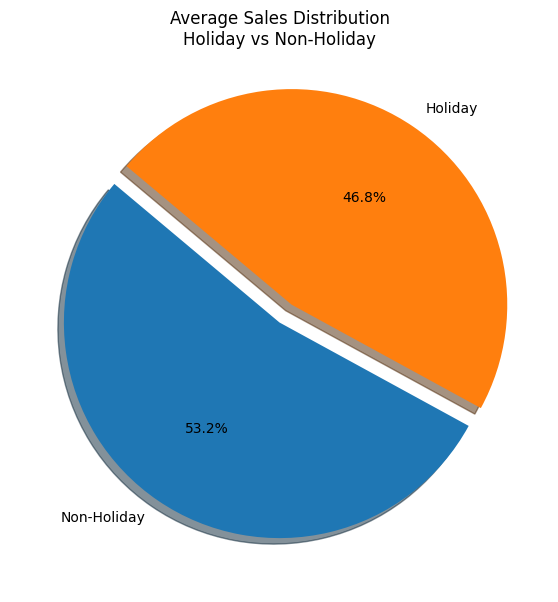

In [16]:
holiday_sales = (
    feature_df.groupby('is_holiday')['sales']
    .mean()
)

labels = ['Non-Holiday', 'Holiday']

explode = (0, 0.1)

plt.figure(figsize=(7,7))

plt.pie(
    holiday_sales,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    shadow=True
)

plt.title(
    "Average Sales Distribution\nHoliday vs Non-Holiday"
)

plt.show()

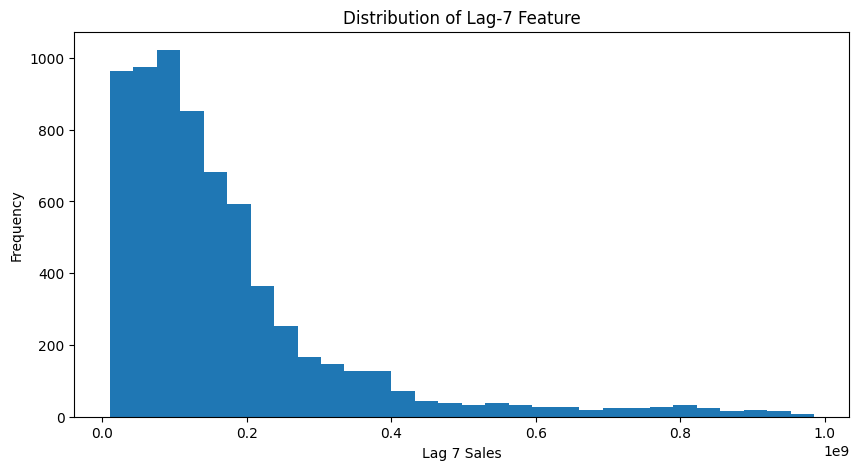

In [17]:
plt.figure(figsize=(10,5))

plt.hist(
    feature_df['lag_7'],
    bins=30
)

plt.title("Distribution of Lag-7 Feature")

plt.xlabel("Lag 7 Sales")

plt.ylabel("Frequency")

plt.show()

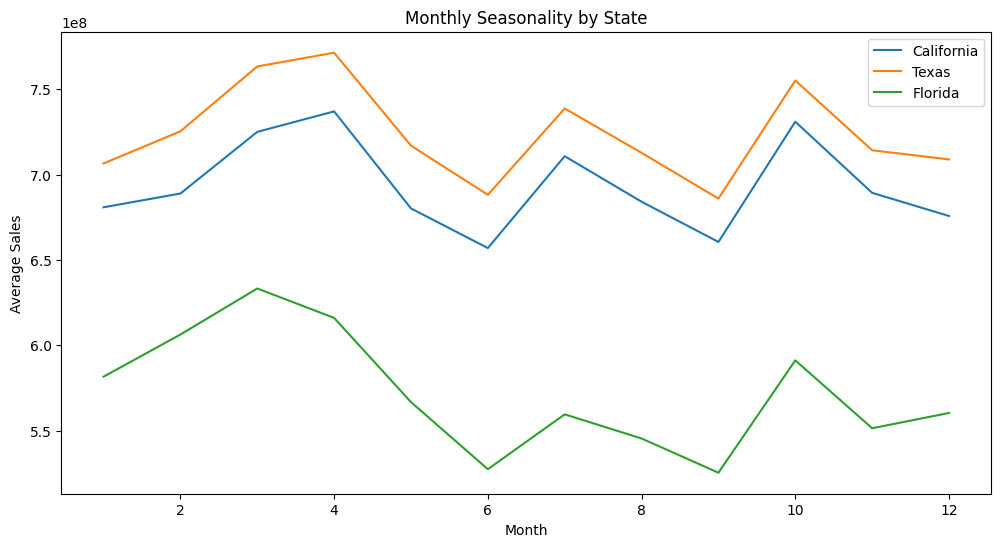

In [18]:
monthly_state_sales = (
    feature_df.groupby(
        ['month', 'state']
    )['sales']
    .mean()
    .reset_index()
)

top_states = ['California', 'Texas', 'Florida']

filtered = monthly_state_sales[
    monthly_state_sales['state'].isin(top_states)
]

plt.figure(figsize=(12,6))

for state in top_states:

    state_data = filtered[
        filtered['state'] == state
    ]

    plt.plot(
        state_data['month'],
        state_data['sales'],
        label=state
    )

plt.legend()

plt.title("Monthly Seasonality by State")

plt.xlabel("Month")

plt.ylabel("Average Sales")

plt.show()